In [1]:
# Copyright (c) Meta Platforms, Inc. and affiliates.

## Video segmentation and tracking with SAM 3

This notebook demonstrates how to use SAM 3 for interactive video segmentation and dense tracking. It covers the following capabilities:

- **Text prompts**: Using natural language descriptions to segment objects (e.g., "person", "shoe")
- **Point prompts**: Adding positive/negative clicks to segment and refine objects

We use the terms _segment_ or _mask_ to refer to the model prediction for an object on a single frame, and _masklet_ to refer to the spatio-temporal masks across the entire video. 

# <a target="_blank" href="https://colab.research.google.com/github/facebookresearch/sam3/blob/main/notebooks/sam3_video_predictor_example.ipynb">
#   <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
# </a>

In [2]:
using_colab = False

In [3]:
if using_colab:
    import torch
    import torchvision
    print("PyTorch version:", torch.__version__)
    print("Torchvision version:", torchvision.__version__)
    print("CUDA is available:", torch.cuda.is_available())
    import sys
    !{sys.executable} -m pip install opencv-python matplotlib scikit-learn
    !{sys.executable} -m pip install 'git+https://github.com/facebookresearch/sam3.git'

In [4]:
!nvidia-smi

Sun May 31 09:15:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.71.05              Driver Version: 595.71.05      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5060 ...    On  |   00000000:01:00.0 Off |                  N/A |
| N/A   46C    P8              4W /   55W |       2MiB /   8151MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Set-up

In this example, we allow running inference either on a single GPU or multiple GPUs.

In [5]:
import os

os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")
os.environ.setdefault("SAM3_LOW_MEMORY", "1")

import sam3
import torch

sam3_root = os.path.join(os.path.dirname(sam3.__file__), "..")

# use all available GPUs on the machine
gpus_to_use = range(torch.cuda.device_count())
# # use only a single GPU
# gpus_to_use = [torch.cuda.current_device()]

/home/umi/sam3/.venv/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [6]:
from sam3.model_builder import build_sam3_video_predictor

predictor = build_sam3_video_predictor(
    gpus_to_use=gpus_to_use,
    checkpoint_path=os.path.join(sam3_root, "model/sam3/sam3.pt"),
)

# Conservative defaults for 8GB GPUs. Increase these if you have headroom.
LOW_MEMORY_MAX_OBJECTS = 8
LOW_MEMORY_DETECTION_THRESHOLD = 0.60
LOW_MEMORY_NEW_OBJECT_THRESHOLD = 0.85

predictor.model.max_num_objects = LOW_MEMORY_MAX_OBJECTS
predictor.model.score_threshold_detection = LOW_MEMORY_DETECTION_THRESHOLD
predictor.model.new_det_thresh = LOW_MEMORY_NEW_OBJECT_THRESHOLD
predictor.model.hotstart_delay = 0
predictor.model.recondition_every_nth_frame = 0
predictor.model.max_trk_keep_alive = min(predictor.model.max_trk_keep_alive, 8)
predictor.model.init_trk_keep_alive = min(predictor.model.init_trk_keep_alive, 8)
predictor.model.detector.async_all_gather = False

INFO 2026-05-31 09:15:56,686 139508 sam3_video_predictor.py: 109: using the following GPU IDs: [0]
INFO 2026-05-31 09:15:57,136 139508 sam3_video_predictor.py: 125: 


	*** START loading model on all ranks ***


INFO 2026-05-31 09:15:57,136 139508 sam3_video_predictor.py: 127: loading model on rank=0 with world_size=1 -- this could take a while ...
INFO 2026-05-31 09:16:00,657 139508 sam3_video_base.py: 348: setting max_num_objects=10000 and num_obj_for_compile=16
INFO 2026-05-31 09:16:02,305 139508 sam3_video_predictor.py: 129: loading model on rank=0 with world_size=1 -- DONE locally
INFO 2026-05-31 09:16:02,306 139508 sam3_video_predictor.py: 140: 


	*** DONE loading model on all ranks ***




#### Inference and visualization utils

In [7]:
import gc
import glob
import os
from contextlib import nullcontext

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from sam3.visualization_utils import (
    load_frame,
    prepare_masks_for_visualization,
    visualize_formatted_frame_output,
)

# font size for axes titles
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["figure.titlesize"] = 12


def _move_outputs_to_cpu(outputs):
    if isinstance(outputs, torch.Tensor):
        return outputs.detach().cpu()
    if isinstance(outputs, dict):
        return {key: _move_outputs_to_cpu(value) for key, value in outputs.items()}
    if isinstance(outputs, (list, tuple)):
        return type(outputs)(_move_outputs_to_cpu(value) for value in outputs)
    return outputs


def propagate_in_video(
    predictor,
    session_id,
    propagation_direction="forward",
    start_frame_index=None,
    max_frame_num_to_track=None,
    use_autocast=True,
    autocast_dtype=torch.bfloat16,
):
    request = dict(
        type="propagate_in_video",
        session_id=session_id,
        propagation_direction=propagation_direction,
    )
    if start_frame_index is not None:
        request["start_frame_index"] = start_frame_index
    if max_frame_num_to_track is not None:
        request["max_frame_num_to_track"] = max_frame_num_to_track

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

    autocast_context = (
        torch.autocast(device_type="cuda", dtype=autocast_dtype)
        if torch.cuda.is_available() and use_autocast
        else nullcontext()
    )

    outputs_per_frame = {}
    try:
        with torch.inference_mode(), autocast_context:
            for response in predictor.handle_stream_request(request=request):
                outputs_per_frame[response["frame_index"]] = _move_outputs_to_cpu(
                    response["outputs"]
                )
                del response
    finally:
        gc.collect()
        if torch.cuda.is_available():
            peak_gib = torch.cuda.max_memory_allocated() / 1024**3
            print(f"propagate peak GPU memory allocated: {peak_gib:.2f} GiB")
            torch.cuda.empty_cache()

    return outputs_per_frame


def get_video_fps(source_video_path, default_fps=30.0):
    if not isinstance(source_video_path, str) or not os.path.isfile(source_video_path):
        return float(default_fps)

    cap = cv2.VideoCapture(source_video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    cap.release()

    if not fps or np.isnan(fps) or fps <= 1e-3:
        return float(default_fps)
    return float(fps)


def parse_video_time_seconds(time_value):
    if isinstance(time_value, (int, float, np.integer, np.floating)):
        return float(time_value)

    parts = str(time_value).strip().split(":")
    if not parts:
        raise ValueError(f"Invalid time value: {time_value}")

    seconds = 0.0
    for part in parts:
        seconds = seconds * 60.0 + float(part)
    return seconds


def format_video_time(seconds):
    seconds = max(0.0, float(seconds))
    hours = int(seconds // 3600)
    minutes = int((seconds % 3600) // 60)
    secs = seconds - hours * 3600 - minutes * 60
    if hours:
        return f"{hours:d}:{minutes:02d}:{secs:06.3f}"
    return f"{minutes:02d}:{secs:06.3f}"


def time_to_frame_index(
    time_value,
    source_video_path=None,
    fps=None,
    num_frames=None,
    rounding="floor",
):
    fps = float(fps) if fps is not None else get_video_fps(source_video_path)
    seconds = parse_video_time_seconds(time_value)
    raw_frame = seconds * fps

    if rounding == "nearest":
        frame_idx = int(round(raw_frame))
    elif rounding == "ceil":
        frame_idx = int(np.ceil(raw_frame))
    elif rounding == "floor":
        frame_idx = int(np.floor(raw_frame))
    else:
        raise ValueError('rounding must be one of "floor", "nearest", or "ceil"')

    if num_frames is not None:
        frame_idx = int(np.clip(frame_idx, 0, max(0, num_frames - 1)))
    return frame_idx


def frame_index_to_time(frame_idx, source_video_path=None, fps=None):
    fps = float(fps) if fps is not None else get_video_fps(source_video_path)
    return int(frame_idx) / fps


def print_video_timing_info(video_frames_for_vis, source_video_path=None, fps=None):
    fps = float(fps) if fps is not None else get_video_fps(source_video_path)
    num_frames = len(video_frames_for_vis)
    duration = num_frames / fps if fps > 0 else 0.0
    last_frame_time = (num_frames - 1) / fps if num_frames and fps > 0 else 0.0
    print(f"fps: {fps:.3f}")
    print(f"frame index range: 0..{max(0, num_frames - 1)} ({num_frames} frames)")
    print(f"duration: {format_video_time(duration)}")
    print(f"last frame starts at: {format_video_time(last_frame_time)}")
    return fps, num_frames


def _to_uint8_rgb(frame):
    frame = np.asarray(frame)
    if frame.ndim == 2:
        frame = np.repeat(frame[..., None], 3, axis=-1)
    if frame.dtype != np.uint8:
        max_value = float(np.nanmax(frame)) if frame.size else 1.0
        if max_value <= 1.0:
            frame = frame * 255.0
        frame = np.clip(frame, 0, 255).astype(np.uint8)
    return frame[..., :3]


def _to_numpy_mask(mask):
    if isinstance(mask, torch.Tensor):
        mask = mask.detach().cpu().numpy()
    mask = np.squeeze(np.asarray(mask))
    if mask.ndim != 2:
        raise ValueError(f"Expected a 2D mask after squeeze, got shape {mask.shape}")
    return mask > 0


def _iter_frame_masks(frame_outputs):
    if not frame_outputs:
        return

    if isinstance(frame_outputs, dict) and "out_binary_masks" in frame_outputs:
        masks = frame_outputs["out_binary_masks"]
        if isinstance(masks, torch.Tensor):
            masks = masks.detach().cpu().numpy()
        masks = np.asarray(masks)
        if masks.ndim >= 3:
            for mask in masks:
                yield mask
        else:
            yield masks
        return

    if isinstance(frame_outputs, dict):
        for mask in frame_outputs.values():
            yield mask


def _combined_mask_for_frame(outputs_per_frame, frame_idx, frame_shape):
    height, width = frame_shape[:2]
    combined = np.zeros((height, width), dtype=bool)
    frame_outputs = outputs_per_frame.get(frame_idx, {})

    for mask in _iter_frame_masks(frame_outputs):
        mask = _to_numpy_mask(mask)
        if mask.shape != (height, width):
            mask = cv2.resize(
                mask.astype(np.uint8),
                (width, height),
                interpolation=cv2.INTER_NEAREST,
            ).astype(bool)
        combined |= mask

    return combined


def save_tracked_objects_green_screen(
    video_frames_for_vis,
    outputs_per_frame,
    out_path,
    source_video_path=None,
    fps=None,
    background_color=(0, 255, 0),
    codec="mp4v",
):
    if not video_frames_for_vis:
        raise ValueError("video_frames_for_vis is empty")

    sample_frame = _to_uint8_rgb(load_frame(video_frames_for_vis[0]))
    height, width = sample_frame.shape[:2]
    fps = float(fps) if fps is not None else get_video_fps(source_video_path)

    os.makedirs(os.path.dirname(out_path) or ".", exist_ok=True)
    writer = cv2.VideoWriter(
        out_path,
        cv2.VideoWriter_fourcc(*codec),
        fps,
        (width, height),
    )
    if not writer.isOpened():
        raise RuntimeError(f"Could not open video writer for {out_path}")

    background_color = np.array(background_color, dtype=np.uint8)
    try:
        for frame_idx, frame_ref in enumerate(video_frames_for_vis):
            frame = _to_uint8_rgb(load_frame(frame_ref))
            if frame.shape[:2] != (height, width):
                frame = cv2.resize(frame, (width, height), interpolation=cv2.INTER_AREA)

            mask = _combined_mask_for_frame(outputs_per_frame, frame_idx, frame.shape)
            canvas = np.empty_like(frame)
            canvas[:] = background_color
            canvas[mask] = frame[mask]
            writer.write(cv2.cvtColor(canvas, cv2.COLOR_RGB2BGR))
    finally:
        writer.release()

    print(f"Saved green-screen tracked-object video to {out_path} ({fps:.2f} fps)")
    return out_path


def show_frame_for_point_prompt(
    video_frames_for_vis,
    frame_idx=0,
    crop=None,
    points_abs=None,
    labels=None,
    grid_step=100,
    figsize=(10, 6),
):
    frame = _to_uint8_rgb(load_frame(video_frames_for_vis[frame_idx]))
    height, width = frame.shape[:2]

    if crop is None:
        x0, y0, x1, y1 = 0, 0, width, height
    else:
        x0, y0, x1, y1 = [int(v) for v in crop]
        x0, x1 = sorted((max(0, x0), min(width, x1)))
        y0, y1 = sorted((max(0, y0), min(height, y1)))

    if x1 <= x0 or y1 <= y0:
        raise ValueError(f"Invalid crop {crop}; frame size is {width}x{height}")

    view = frame[y0:y1, x0:x1]
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(view, origin="upper", extent=(x0, x1, y1, y0))
    ax.set_xlim(x0, x1)
    ax.set_ylim(y1, y0)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"Frame {frame_idx}: absolute pixel coordinates [x, y]")

    if grid_step:
        grid_step = max(1, int(grid_step))
        x_start = (x0 // grid_step) * grid_step
        y_start = (y0 // grid_step) * grid_step
        ax.set_xticks(np.arange(x_start, x1 + 1, grid_step))
        ax.set_yticks(np.arange(y_start, y1 + 1, grid_step))
        ax.grid(color="yellow", alpha=0.35, linewidth=0.8)

    if points_abs is not None:
        points_abs = np.asarray(points_abs)
        if points_abs.ndim == 1:
            points_abs = points_abs[None, :]
        labels_arr = (
            np.ones(len(points_abs), dtype=np.int32)
            if labels is None
            else np.asarray(labels)
        )

        for target_label, color, marker, name in [
            (1, "lime", "*", "positive"),
            (0, "red", "x", "negative"),
        ]:
            selected = labels_arr == target_label
            if selected.any():
                ax.scatter(
                    points_abs[selected, 0],
                    points_abs[selected, 1],
                    c=color,
                    marker=marker,
                    s=140,
                    linewidths=1.5,
                    label=name,
                )

        for idx, (x, y) in enumerate(points_abs[:, :2]):
            ax.text(
                x + 4,
                y + 4,
                f"{idx}: ({int(x)}, {int(y)})",
                color="white",
                fontsize=9,
                bbox=dict(facecolor="black", alpha=0.6, pad=2),
            )
        ax.legend(loc="upper right")

    plt.show()
    return fig, ax


def show_frame_at_time(
    video_frames_for_vis,
    time_value,
    source_video_path=None,
    fps=None,
    rounding="floor",
    crop=None,
    points_abs=None,
    labels=None,
    grid_step=100,
    figsize=(10, 6),
):
    fps = float(fps) if fps is not None else get_video_fps(source_video_path)
    frame_idx = time_to_frame_index(
        time_value,
        fps=fps,
        num_frames=len(video_frames_for_vis),
        rounding=rounding,
    )
    frame_time = frame_index_to_time(frame_idx, fps=fps)
    print(
        f"{time_value} -> frame_idx {frame_idx} "
        f"(frame starts at {format_video_time(frame_time)}, fps={fps:.3f})"
    )
    return show_frame_for_point_prompt(
        video_frames_for_vis,
        frame_idx=frame_idx,
        crop=crop,
        points_abs=points_abs,
        labels=labels,
        grid_step=grid_step,
        figsize=figsize,
    )


def abs_to_rel_coords(coords, IMG_WIDTH, IMG_HEIGHT, coord_type="point"):
    """Convert absolute coordinates to relative coordinates (0-1 range)

    Args:
        coords: List of coordinates
        coord_type: 'point' for [x, y] or 'box' for [x, y, w, h]
    """
    if coord_type == "point":
        return [[x / IMG_WIDTH, y / IMG_HEIGHT] for x, y in coords]
    elif coord_type == "box":
        return [
            [x / IMG_WIDTH, y / IMG_HEIGHT, w / IMG_WIDTH, h / IMG_HEIGHT]
            for x, y, w, h in coords
        ]
    else:
        raise ValueError(f"Unknown coord_type: {coord_type}")

### Loading an example video

We assume that the video is stored as either **a list of JPEG frames with filenames like `<frame_index>.jpg`** or **an MP4 video**.

Note that you can extract their JPEG frames using ffmpeg (https://ffmpeg.org/) as follows:
```
ffmpeg -i <your_video>.mp4 -q:v 2 -start_number 0 <output_dir>/'%05d.jpg'
```
where `-q:v` generates high-quality JPEG frames and `-start_number 0` asks ffmpeg to start the JPEG file from `00000.jpg`.

In [8]:
# "video_path" needs to be either a JPEG folder or a MP4 video file
file_name = "10.mp4"
video_path = f"{sam3_root}/input/{file_name}"

In [9]:
# load "video_frames_for_vis" for visualization purposes (they are not used by the model)
if isinstance(video_path, str) and video_path.endswith(".mp4"):
    cap = cv2.VideoCapture(video_path)
    video_frames_for_vis = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        video_frames_for_vis.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    cap.release()
else:
    video_frames_for_vis = glob.glob(os.path.join(video_path, "*.jpg"))
    try:
        # integer sort instead of string sort (so that e.g. "2.jpg" is before "11.jpg")
        video_frames_for_vis.sort(
            key=lambda p: int(os.path.splitext(os.path.basename(p))[0])
        )
    except ValueError:
        # fallback to lexicographic sort if the format is not "<frame_index>.jpg"
        print(
            f'frame names are not in "<frame_index>.jpg" format: {video_frames_for_vis[:5]=}, '
            f"falling back to lexicographic sort."
        )
        video_frames_for_vis.sort()

### Opening an inference session on this video

SAM 3 requires stateful inference for interactive video segmentation, so we need to initialize an **inference session** on this video.

During initialization, it loads all the video frames and stores their pixels in the session state.

In [10]:
response = predictor.handle_request(
    request=dict(
        type="start_session",
        resource_path=video_path,
        offload_video_to_cpu=True,
        offload_state_to_cpu=True,
    )
)
session_id = response["session_id"]

frame loading (OpenCV) [rank=0]: 100%|██████████| 95/95 [00:00<00:00, 482.66it/s]
INFO 2026-05-31 09:16:05,611 139508 sam3_base_predictor.py: 147: started new session 0f424942-21b4-4ad0-9c83-07fbae6fcd1d


### Video promptable concept segmentation with text

Using SAM 3 you can describe objects using natural language, and the model will automatically detect and track all instances of that object throughout the video.

In the example below, we add a text prompt on frame 0 and propagation throughout the video. Here we use the text prompt "person" to detect all people in the video. SAM 3 will automatically identify multiple person instances and assign each a unique object ID.

Note that the first call might be slower due to setting up buffers. **You can rerun all the cells below when measuring speed.**

In [11]:
# note: in case you already ran one text prompt and now want to switch to another text prompt
# it's required to reset the session first (otherwise the results would be wrong)
_ = predictor.handle_request(
    request=dict(
        type="reset_session",
        session_id=session_id,
    )
)

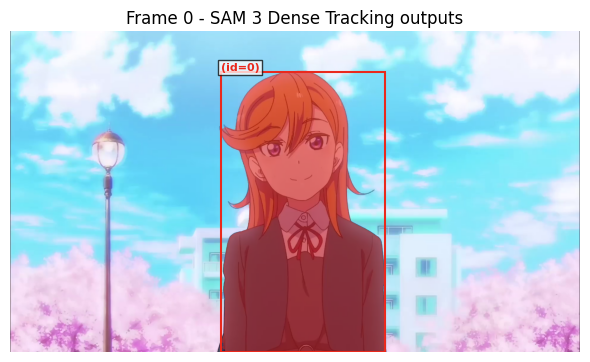

In [12]:
prompt_text_str = "person"  # the text prompt to add on frame 0
frame_idx = 0  # add a text prompt on frame 0
response = predictor.handle_request(
    request=dict(
        type="add_prompt",
        session_id=session_id,
        frame_index=frame_idx,
        text=prompt_text_str,
    )
)
out = response["outputs"]

plt.close("all")
visualize_formatted_frame_output(
    frame_idx,
    video_frames_for_vis,
    outputs_list=[prepare_masks_for_visualization({frame_idx: out})],
    titles=["SAM 3 Dense Tracking outputs"],
    figsize=(6, 4),
)

propagate_in_video:   0%|          | 0/95 [00:00<?, ?it/s]

INFO 2026-05-31 09:19:02,320 139508 sam3_base_predictor.py: 312: propagation ended in session 0f424942-21b4-4ad0-9c83-07fbae6fcd1d


propagate peak GPU memory allocated: 7.11 GiB


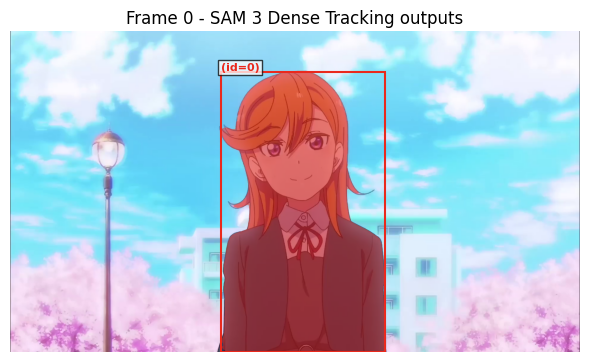

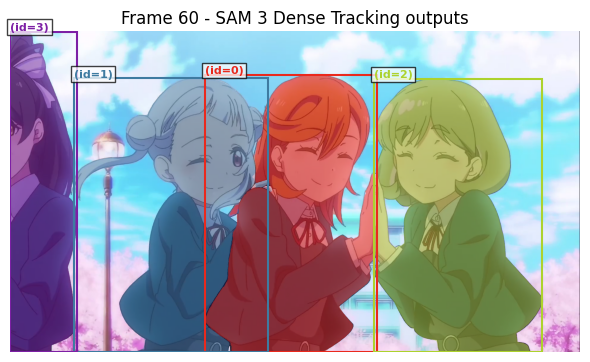

In [13]:
# now we propagate the outputs from frame 0 to the end of the video and collect all outputs
outputs_per_frame = propagate_in_video(predictor, session_id)

# finally, we reformat the outputs for visualization and plot the outputs every 60 frames
outputs_per_frame = prepare_masks_for_visualization(outputs_per_frame)

vis_frame_stride = 60
plt.close("all")
for frame_idx in range(0, len(outputs_per_frame), vis_frame_stride):
    visualize_formatted_frame_output(
        frame_idx,
        video_frames_for_vis,
        outputs_list=[outputs_per_frame],
        titles=["SAM 3 Dense Tracking outputs"],
        figsize=(6, 4),
    )

###  Removing objects

We can remove individual objects using their id.

As an example, let's remove object 2 (which is the dancer in the front).

In [ ]:
# we pick id 2, which is the dancer in the front
obj_id = 2
response = predictor.handle_request(
    request=dict(
        type="remove_object",
        session_id=session_id,
        obj_id=obj_id,
    )
)

In [ ]:
# now we propagate the outputs from frame 0 to the end of the video and collect all outputs
outputs_per_frame = propagate_in_video(predictor, session_id)

# finally, we reformat the outputs for visualization and plot the outputs every 60 frames
outputs_per_frame = prepare_masks_for_visualization(outputs_per_frame)

vis_frame_stride = 60
plt.close("all")
for frame_idx in range(0, len(outputs_per_frame), vis_frame_stride):
    visualize_formatted_frame_output(
        frame_idx,
        video_frames_for_vis,
        outputs_list=[outputs_per_frame],
        titles=["SAM 3 Dense Tracking outputs"],
        figsize=(6, 4),
    )

### Adding new objects with point prompts

We can add new objects through point prompts.

Assuming that we've changed our mind, and now that we want to add back the dancer in the front (whom we just removed in the step above). We can use interactive clicks to add her back.

In [ ]:
sample_img = Image.fromarray(load_frame(video_frames_for_vis[0]))

IMG_WIDTH, IMG_HEIGHT = sample_img.size

In [ ]:
# Use this to read point-prompt coordinates without interactive clicking.
# Coordinates are absolute pixels: [x, y], measured from the top-left corner.
print_video_timing_info(video_frames_for_vis, video_path)

# Copy the timestamp from your video player here. Supported formats: seconds, "MM:SS.sss", or "HH:MM:SS.sss".
prompt_time = "00:02.050"  # change this to the time where the object is visible
prompt_frame_idx = time_to_frame_index(
    prompt_time,
    source_video_path=video_path,
    num_frames=len(video_frames_for_vis),
    rounding="floor",
)
frame_idx = prompt_frame_idx
print(
    f"prompt_time {prompt_time} -> frame_idx {prompt_frame_idx}; "
    f"frame starts at {format_video_time(frame_index_to_time(prompt_frame_idx, source_video_path=video_path))}"
)
show_frame_for_point_prompt(
    video_frames_for_vis,
    frame_idx=frame_idx,
    grid_step=100,
    figsize=(10, 6),
)

# For a more precise reading, zoom into a region and use a smaller grid.
# show_frame_for_point_prompt(
#     video_frames_for_vis,
#     frame_idx=prompt_frame_idx,
#     crop=(650, 350, 900, 700),  # x0, y0, x1, y1
#     grid_step=25,
#     figsize=(8, 8),
# )

In [ ]:
# let's add back the dancer via point prompts.
# we will use a single positive click to add the dancer back.
# Replace the coordinate below with [x, y] read from the helper cell above.
# Use a later frame here if the object is not visible on frame 0.

frame_idx = prompt_frame_idx if "prompt_frame_idx" in globals() else 0
obj_id = 4
points_abs = np.array(
    [
        [1900, 200],  # positive click
    ]
)
# positive clicks have label 1, while negative clicks have label 0
labels = np.array([1])

In [ ]:
# convert points and labels to tensors; also convert to relative coordinates
points_tensor = torch.tensor(
    abs_to_rel_coords(points_abs, IMG_WIDTH, IMG_HEIGHT, coord_type="point"),
    dtype=torch.float32,
)
points_labels_tensor = torch.tensor(labels, dtype=torch.int32)

response = predictor.handle_request(
    request=dict(
        type="add_prompt",
        session_id=session_id,
        frame_index=frame_idx,
        points=points_tensor,
        point_labels=points_labels_tensor,
        obj_id=obj_id,
    )
)
out = response["outputs"]

plt.close("all")
visualize_formatted_frame_output(
    frame_idx,
    video_frames_for_vis,
    outputs_list=[prepare_masks_for_visualization({frame_idx: out})],
    titles=["SAM 3 Dense Tracking outputs"],
    figsize=(6, 4),
    points_list=[points_abs],
    points_labels_list=[labels],
)

In [ ]:
# Propagate from the point-prompt frame forward.
# If the object was already visible before this frame, use propagation_direction="both" instead.
outputs_per_frame = propagate_in_video(
    predictor,
    session_id,
    start_frame_index=frame_idx,
)

# finally, we reformat the outputs for visualization and plot the outputs every 60 frames
outputs_per_frame = prepare_masks_for_visualization(outputs_per_frame)

vis_frame_stride = 60
plt.close("all")
for frame_idx in range(0, len(outputs_per_frame), vis_frame_stride):
    visualize_formatted_frame_output(
        frame_idx,
        video_frames_for_vis,
        outputs_list=[outputs_per_frame],
        titles=["SAM 3 Dense Tracking outputs"],
        figsize=(6, 4),
    )

### Refining an existing object with point prompts

We can also refine the segmentation mask of an existing object through point prompts.

Assuming that we've changed our mind (again) -- for Object ID 2 (the dancer in the front whom we just added back in the step above), now we only want to segment her T-shirt instead of her whole body. We can adjust the segmentation mask with a few more positive and negative clicks.

In [ ]:
# For the dancer in the front, suppose now we only want to segment her T-shirt instead of her whole body
# we will use 2 positive clicks and 2 negative clicks to select her shirt.
# Replace these coordinates with [x, y] values read from the helper cell above.

frame_idx = 0
obj_id = 2
points_abs = np.array(
    [
        [740, 450],  # positive click
        [760, 630],  # negative click
        [840, 640],  # negative click
        [760, 550],  # positive click
    ]
)
# positive clicks have label 1, while negative clicks have label 0
labels = np.array([1, 0, 0, 1])

In [ ]:
# convert points and labels to tensors; also convert to relative coordinates
points_tensor = torch.tensor(
    abs_to_rel_coords(points_abs, IMG_WIDTH, IMG_HEIGHT, coord_type="point"),
    dtype=torch.float32,
)
points_labels_tensor = torch.tensor(labels, dtype=torch.int32)

response = predictor.handle_request(
    request=dict(
        type="add_prompt",
        session_id=session_id,
        frame_index=frame_idx,
        points=points_tensor,
        point_labels=points_labels_tensor,
        obj_id=obj_id,
    )
)
out = response["outputs"]

plt.close("all")
visualize_formatted_frame_output(
    frame_idx,
    video_frames_for_vis,
    outputs_list=[prepare_masks_for_visualization({frame_idx: out})],
    titles=["SAM 3 Dense Tracking outputs"],
    figsize=(6, 4),
    points_list=[points_abs],
    points_labels_list=[labels],
)

In [ ]:
# now we propagate the outputs from frame 0 to the end of the video and collect all outputs
outputs_per_frame = propagate_in_video(predictor, session_id)

# finally, we reformat the outputs for visualization and plot the outputs every 60 frames
outputs_per_frame = prepare_masks_for_visualization(outputs_per_frame)

vis_frame_stride = 60
plt.close("all")
for frame_idx in range(0, len(outputs_per_frame), vis_frame_stride):
    visualize_formatted_frame_output(
        frame_idx,
        video_frames_for_vis,
        outputs_list=[outputs_per_frame],
        titles=["SAM 3 Dense Tracking outputs"],
        figsize=(6, 4),
    )

### Close session

Each session is tied to a single video. We can close the session after inference to free up its resources.

(Then, you may start a new session on another video.)

In [ ]:
# finally, close the inference session to free its GPU resources
# (you may start a new session on another video)
_ = predictor.handle_request(
    request=dict(
        type="close_session",
        session_id=session_id,
    )
)

### Clean-up

After all inference is done, we can shutdown the predictor to free up the multi-GPU process group.

In [ ]:
# after all inference is done, we can shutdown the predictor
# to free up the multi-GPU process group
predictor.shutdown()

In [ ]:
# Export the current tracked objects with the background replaced by green.
# Run this after outputs_per_frame has been created and formatted with prepare_masks_for_visualization.
green_screen_output_path = os.path.join(sam3_root, "output", f"{file_name.split(".")[0]}_tracked_green.mp4")

save_tracked_objects_green_screen(
    video_frames_for_vis=video_frames_for_vis,
    outputs_per_frame=outputs_per_frame,
    out_path=green_screen_output_path,
    source_video_path=video_path,
    background_color=(0, 255, 0),
)